# PBMC manuscript figures

This notebook is **visualization-only**. It consumes the frozen PBMC AnnData
object and numerical outputs produced by the benchmark and GLMM scripts.

It does not fit classifiers, rerun donor CV, rerun group transfer, or fit mixed models.

In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src" / "scrna_benchmark").is_dir():
            return p
    raise RuntimeError("Run this notebook from inside the repository.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from scrna_benchmark.plotting import (
    DEFAULT_REP_LABELS,
    DEFAULT_REP_ORDER,
    load_per_class_f1_matrix,
    plot_batch_covariate_by_scheme,
    plot_confusion_matrix_from_predictions,
    plot_donor_ablation,
    plot_glmm_scheme_comparison,
    plot_group_transfer,
    plot_per_class_f1_heatmap,
    plot_random_vs_donor_cv,
)

ADATA_PATH = REPO_ROOT / "data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad"
PRIMARY_DIR = REPO_ROOT / "results/pbmc_no_batch"
SITE_DIR = REPO_ROOT / "results/pbmc_with_site_covariate"
QC_DIR = REPO_ROOT / "results/preprocessing/pbmc"
FIG_DIR = REPO_ROOT / "figures/pbmc"
CACHE_DIR = REPO_ROOT / "results/figure_data"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(REPO_ROOT)

/users/xchen5/scRNA-cross-donor-generalization


## Check required numerical outputs

In [2]:
TRANSFER_SUMMARY = (
    PRIMARY_DIR
    / "group_transfer"
    / "Cambridge_vs_Ncl"
    / "group_transfer_summary.csv"
)

required = [
    ADATA_PATH,
    PRIMARY_DIR / "random_split/random_split_repeated_metrics.csv",
    PRIMARY_DIR / "donor_cv/metrics.csv",
    PRIMARY_DIR / "donor_ablation/donor_ablation_summary.csv",
    TRANSFER_SUMMARY,
    SITE_DIR / "random_split/random_split_repeated_metrics.csv",
    SITE_DIR / "donor_cv/metrics.csv",
    PRIMARY_DIR / "mixed_models/correctness_glmm_predicted_probabilities.csv",
]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing required result files: {missing}")
print("All required numerical outputs are available.")

All required numerical outputs are available.


## Dataset overview

,cells,HVGs,donors,cell_types,sites,PCA_dims,Harmony_dims,scVI_dims
0,10107,1000,23,13,2,15,15,10


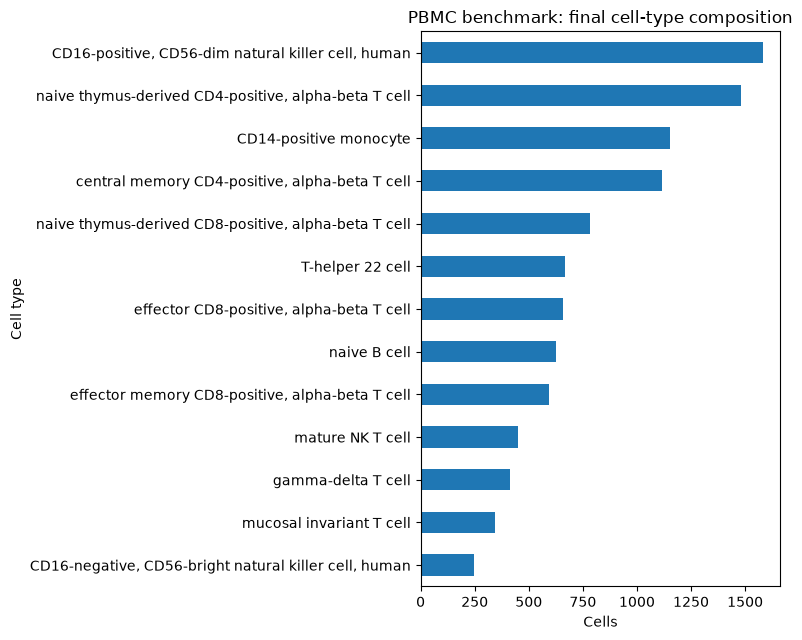

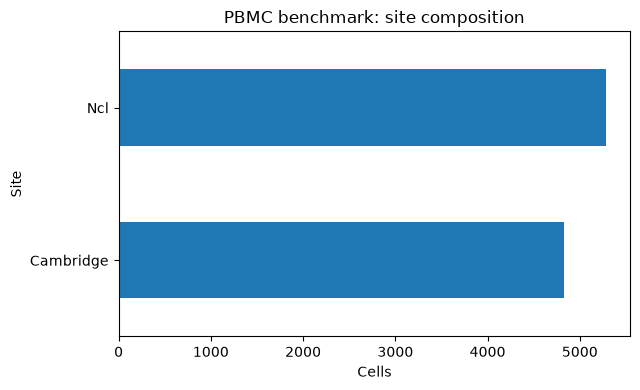

In [3]:
adata_backed = ad.read_h5ad(ADATA_PATH, backed="r")
overview = pd.DataFrame([{
    "cells": adata_backed.n_obs,
    "HVGs": adata_backed.n_vars,
    "donors": adata_backed.obs["patient_id"].astype(str).nunique(),
    "cell_types": adata_backed.obs["cell_type"].astype(str).nunique(),
    "sites": adata_backed.obs["Site"].astype(str).nunique(),
    "PCA_dims": adata_backed.obsm["X_pca"].shape[1],
    "Harmony_dims": adata_backed.obsm["X_harmony"].shape[1],
    "scVI_dims": adata_backed.obsm["X_scVI"].shape[1],
}])
display(overview)

celltype_counts = adata_backed.obs["cell_type"].astype(str).value_counts().sort_values()
site_counts = adata_backed.obs["Site"].astype(str).value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 6.5))
celltype_counts.plot.barh(ax=ax)
ax.set_xlabel("Cells")
ax.set_ylabel("Cell type")
ax.set_title("PBMC benchmark: final cell-type composition")
fig.tight_layout()
fig.savefig(FIG_DIR / "pbmc_celltype_composition.pdf", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4))
site_counts.plot.barh(ax=ax)
ax.set_xlabel("Cells")
ax.set_ylabel("Site")
ax.set_title("PBMC benchmark: site composition")
fig.tight_layout()
fig.savefig(FIG_DIR / "pbmc_site_composition.pdf", bbox_inches="tight")
plt.show()

if hasattr(adata_backed, "file") and adata_backed.file is not None:
    adata_backed.file.close()

## PCA-derived UMAPs (figure artifact only)

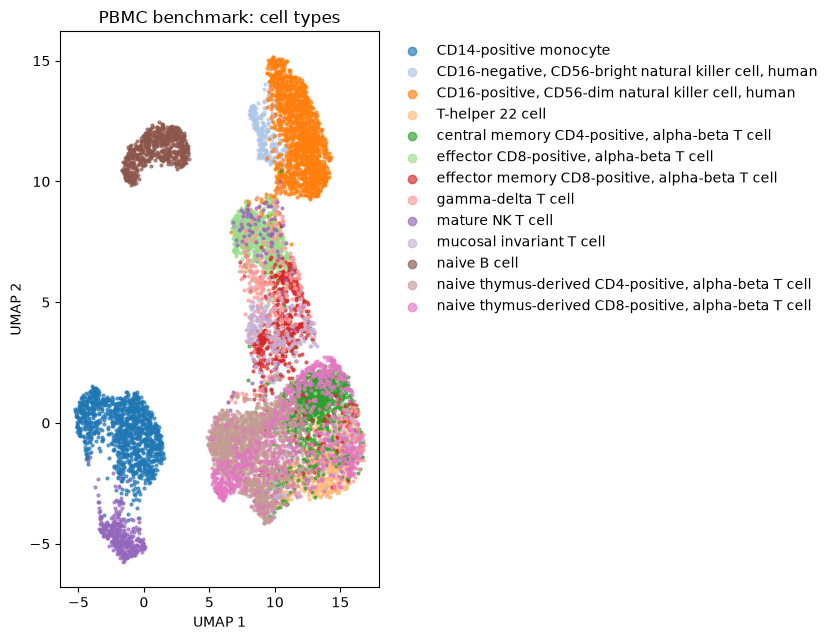

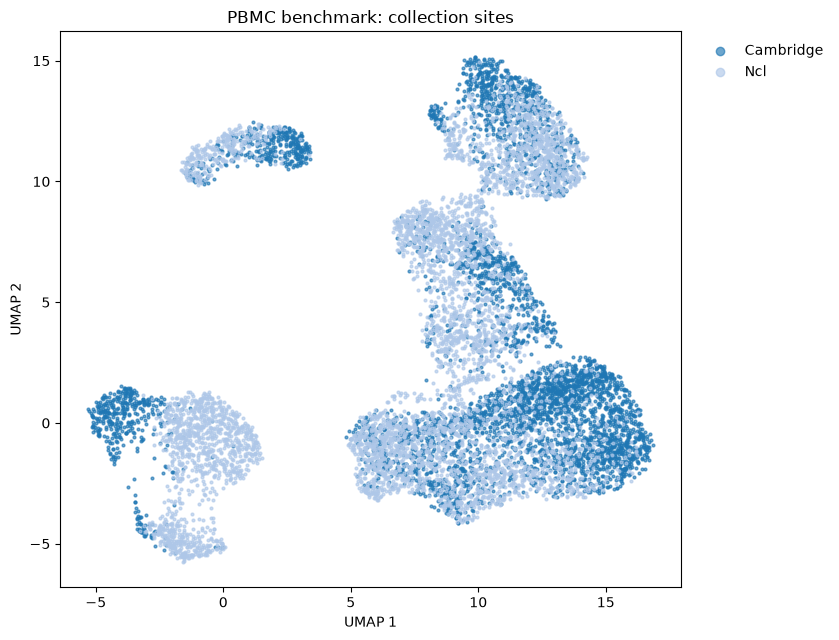

In [4]:
def get_or_make_umap():
    cache = CACHE_DIR / "pbmc_umap_pca.csv"
    if cache.exists():
        return pd.read_csv(cache, index_col=0)

    adata = ad.read_h5ad(ADATA_PATH)
    sc.pp.neighbors(adata, use_rep="X_pca", random_state=42)
    sc.tl.umap(adata, random_state=42)
    coords = pd.DataFrame(
        adata.obsm["X_umap"],
        index=adata.obs_names.astype(str),
        columns=["UMAP1", "UMAP2"],
    )
    coords["cell_type"] = adata.obs["cell_type"].astype(str).to_numpy()
    coords["Site"] = adata.obs["Site"].astype(str).to_numpy()
    coords["patient_id"] = adata.obs["patient_id"].astype(str).to_numpy()
    coords.to_csv(cache)
    return coords

def plot_categorical_umap(coords, column, title, out_name):
    categories = sorted(coords[column].astype(str).unique())
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    cmap = plt.get_cmap("tab20", max(20, len(categories)))
    for i, label in enumerate(categories):
        sub = coords[coords[column].astype(str) == label]
        ax.scatter(
            sub["UMAP1"], sub["UMAP2"],
            s=4, alpha=0.65, label=label, color=cmap(i), rasterized=True,
        )
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / out_name, bbox_inches="tight")
    plt.show()

coords = get_or_make_umap()
plot_categorical_umap(
    coords, "cell_type",
    "PBMC benchmark: cell types",
    "pbmc_umap_celltype.pdf",
)
plot_categorical_umap(
    coords, "Site",
    "PBMC benchmark: collection sites",
    "pbmc_umap_site.pdf",
)

## Random cell-level split vs donor-held-out evaluation

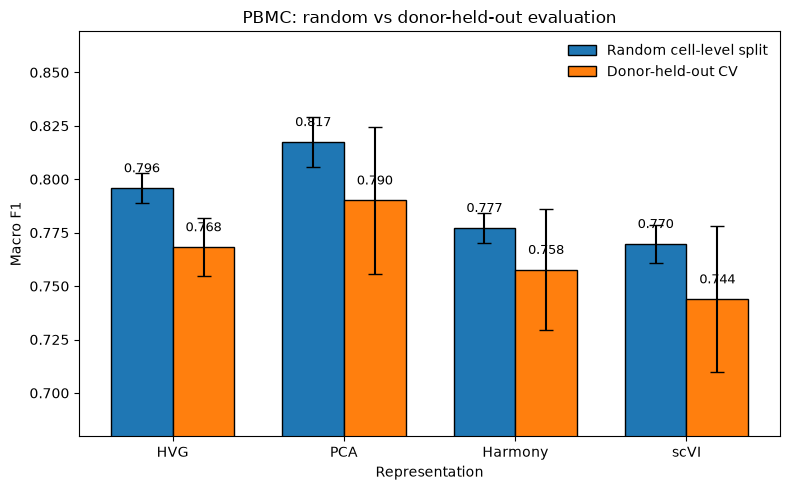

In [5]:
plot_random_vs_donor_cv(
    PRIMARY_DIR / "random_split/random_split_repeated_metrics.csv",
    PRIMARY_DIR / "donor_cv/metrics.csv",
    out_file=FIG_DIR / "pbmc_random_vs_donor.pdf",
    title="PBMC: random vs donor-held-out evaluation",
)
plt.show()

## Site-covariate sensitivity

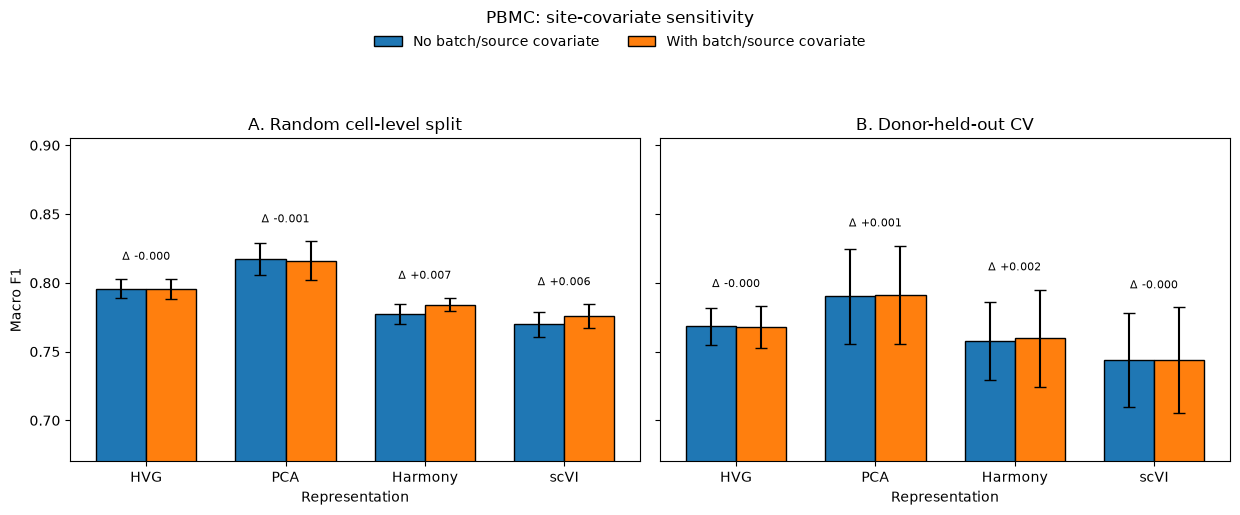

In [6]:
plot_batch_covariate_by_scheme(
    PRIMARY_DIR / "donor_cv/metrics.csv",
    SITE_DIR / "donor_cv/metrics.csv",
    out_file=FIG_DIR / "pbmc_site_covariate_sensitivity.pdf",
    title="PBMC: site-covariate sensitivity",
)
plt.show()

## Donor-ablation analysis

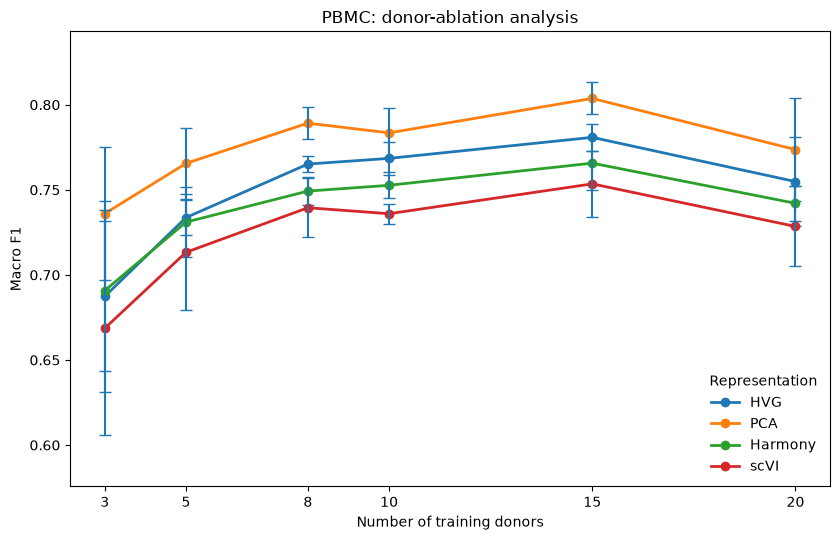

In [7]:
plot_donor_ablation(
    PRIMARY_DIR / "donor_ablation/donor_ablation_summary.csv",
    out_file=FIG_DIR / "pbmc_donor_ablation.pdf",
    title="PBMC: donor-ablation analysis",
)
plt.show()

## Per-class donor-held-out F1

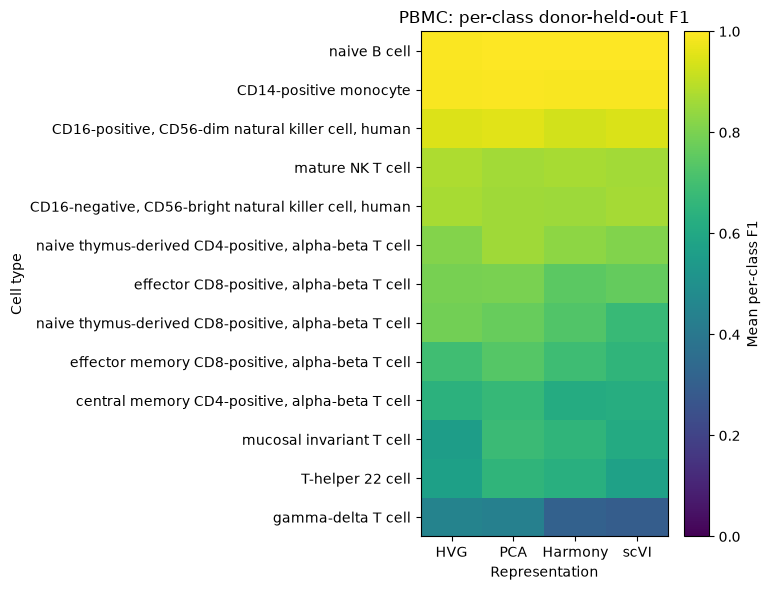

In [8]:
f1_matrix = load_per_class_f1_matrix(PRIMARY_DIR / "donor_cv")
plot_per_class_f1_heatmap(
    f1_matrix,
    annotate=False,
    out_file=FIG_DIR / "pbmc_per_class_f1.pdf",
    title="PBMC: per-class donor-held-out F1",
)
plt.show()

## Representative pooled donor-CV confusion matrix

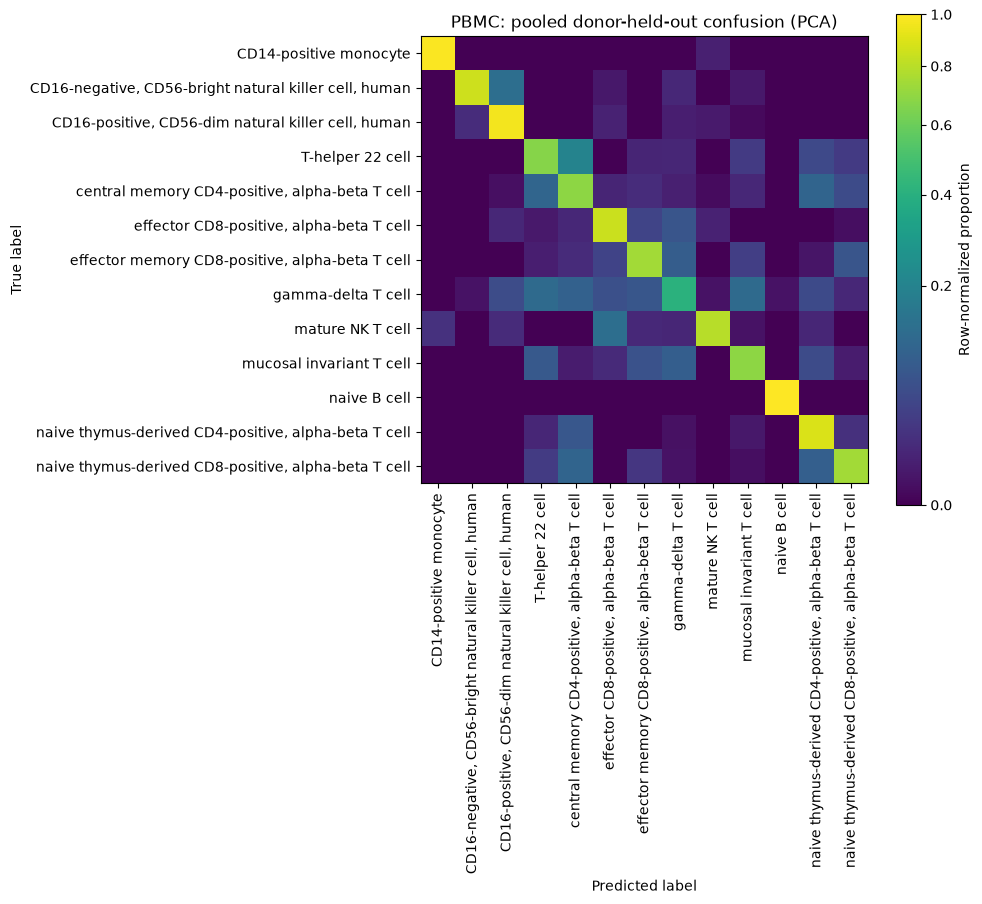

In [9]:
# Preserve the representative choice used in the legacy PBMC notebook.
REPRESENTATIVE_REP = "pca"
pred_path = PRIMARY_DIR / "donor_cv" / f"donor_cv_{REPRESENTATIVE_REP}_all_predictions.csv"
plot_confusion_matrix_from_predictions(
    pred_path,
    out_file=FIG_DIR / f"pbmc_{REPRESENTATIVE_REP}_confusion.pdf",
    title=f"PBMC: pooled donor-held-out confusion ({DEFAULT_REP_LABELS[REPRESENTATIVE_REP]})",
)
plt.show()

## Cambridge ↔ Newcastle transfer

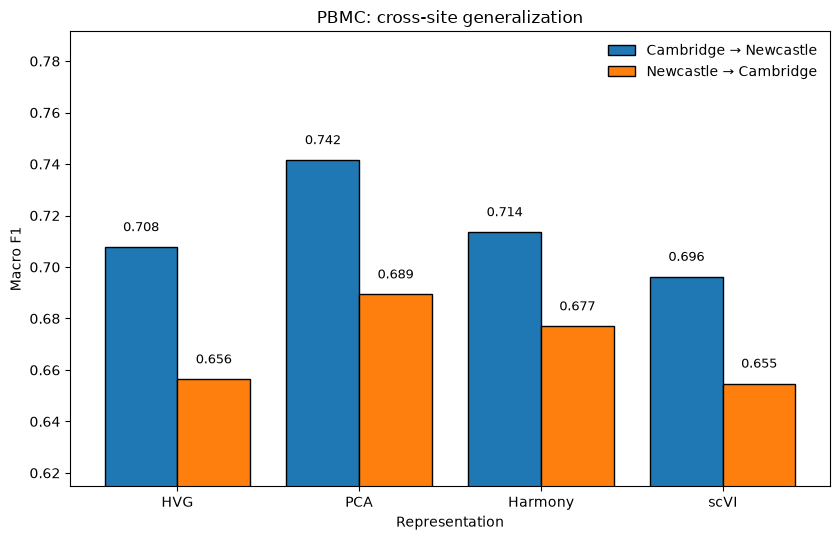

In [10]:
plot_group_transfer(
    TRANSFER_SUMMARY,
    group_label_map={"Cambridge": "Cambridge", "Ncl": "Newcastle"},
    out_file=FIG_DIR / "pbmc_cross_site_transfer.pdf",
    title="PBMC: cross-site generalization",
)
plt.show()

# PBMC additional analysis cells — paste after the existing Cambridge ↔ Ncl transfer section

These cells address why `Cambridge → Ncl` and `Ncl → Cambridge` have different macro-F1 despite nearly matched gross cohort sizes.

They add three targeted diagnostics without changing the primary PBMC benchmark:

1. site × cell-type cell/donor support table and per-class F1 asymmetry;
2. repeated **cell-type support-matched** transfer;
3. repeated **donor-count-matched** transfer (11 vs 11 donors) as a direct check that 11 vs 12 total donors is not driving the direction effect.

Outputs go under the existing transfer result directory in a new `diagnostics/` subfolder.

In [11]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from IPython.display import display

HERE = Path.cwd().resolve()
REPO_ROOT = next((p for p in [HERE, *HERE.parents] if (p / "src/scrna_benchmark").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repository root")
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from scrna_benchmark.diagnostics import (
    group_celltype_support,
    run_donor_count_matched_group_transfer,
    run_support_matched_group_transfer,
    summarize_transfer_sensitivity,
)

# Reuse an in-memory adata from the PBMC notebook if present; otherwise load the
# current benchmark-ready checkpoint.
if "adata" not in globals():
    adata = sc.read_h5ad(REPO_ROOT / "data/PBMC_Stephenson/stephenson_benchmark_ready.h5ad")

GROUP_COL = "Site"
GROUP_A = "Cambridge"
GROUP_B = "Ncl"
CELLTYPE_COL = "cell_type"
DONOR_COL = "patient_id"
REPRESENTATIONS = {
    "hvg": "hvg",
    "pca": "X_pca",
    "harmony": "X_harmony",
    "scvi": "X_scVI",
}
REPRESENTATIONS = {
    k: v for k, v in REPRESENTATIONS.items()
    if v == "hvg" or v in adata.obsm
}

TRANSFER_DIR = REPO_ROOT / "results/pbmc_no_batch/group_transfer/Cambridge_vs_Ncl"
DIAG_DIR = TRANSFER_DIR / "diagnostics"
FIG_DIR = REPO_ROOT / "figures/pbmc_no_batch/group_transfer/diagnostics"
DIAG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Site × cell-type training support

Because macro-F1 weights classes equally, a site's *test-set class proportions* do not directly weight the final score. But highly unequal **training support per class** can still change the fitted logistic-regression boundary. This table therefore counts both cells and donors supporting each class at each site.

In [12]:
support_long = group_celltype_support(
    adata.obs,
    group_col=GROUP_COL,
    celltype_col=CELLTYPE_COL,
    donor_col=DONOR_COL,
)
support_long.to_csv(DIAG_DIR / "site_celltype_support_long.csv", index=False)

cells_wide = support_long.pivot(index=CELLTYPE_COL, columns=GROUP_COL, values="n_cells").fillna(0)
donors_wide = support_long.pivot(index=CELLTYPE_COL, columns=GROUP_COL, values="n_donors").fillna(0)
support_table = pd.DataFrame(index=sorted(set(cells_wide.index) | set(donors_wide.index)))
support_table["Cambridge_cells"] = cells_wide.get(GROUP_A, pd.Series(dtype=float))
support_table["Ncl_cells"] = cells_wide.get(GROUP_B, pd.Series(dtype=float))
support_table["Cambridge_donors"] = donors_wide.get(GROUP_A, pd.Series(dtype=float))
support_table["Ncl_donors"] = donors_wide.get(GROUP_B, pd.Series(dtype=float))
support_table = support_table.fillna(0)
support_table["log_cell_support_ratio_Cambridge_over_Ncl"] = np.log(
    (support_table["Cambridge_cells"] + 0.5) / (support_table["Ncl_cells"] + 0.5)
)
support_table.to_csv(DIAG_DIR / "site_celltype_support_wide.csv")
display(support_table.sort_values("log_cell_support_ratio_Cambridge_over_Ncl"))

site_totals = (
    adata.obs.groupby(GROUP_COL, observed=True)
    .agg(n_cells=(CELLTYPE_COL, "size"), n_donors=(DONOR_COL, "nunique"))
)
display(site_totals.loc[[g for g in [GROUP_A, GROUP_B] if g in site_totals.index]])

,Cambridge_cells,Ncl_cells,Cambridge_donors,Ncl_donors,log_cell_support_ratio_Cambridge_over_Ncl
mature NK T cell,76,373,10,12,-1.585627
CD14-positive monocyte,353,800,11,12,-0.817353
"effector CD8-positive, alpha-beta T cell",217,439,10,10,-0.703439
gamma-delta T cell,147,267,11,10,-0.595291
"CD16-negative, CD56-bright natural killer cell, human",92,155,11,12,-0.519437
"effector memory CD8-positive, alpha-beta T cell",236,356,11,10,-0.410386
"naive thymus-derived CD4-positive, alpha-beta T cell",667,812,11,10,-0.196577
mucosal invariant T cell,157,189,11,10,-0.184964
"CD16-positive, CD56-dim natural killer cell, human",732,850,11,12,-0.149361
"naive thymus-derived CD8-positive, alpha-beta T cell",402,379,11,10,0.058841


,n_cells,n_donors
Site,,
Cambridge,4827,11
Ncl,5280,12


## B. Per-class directional F1 vs training-support asymmetry

The current transfer run already saved direction-specific per-class tables. We merge them with the support table rather than rerunning the original transfer.

,cell_type,Cambridge_cells,Ncl_cells,Cambridge_donors,Ncl_donors,log_cell_support_ratio_Cambridge_over_Ncl,f1_Cambridge_to_Ncl,f1_Ncl_to_Cambridge,delta_f1_Cambridge_to_Ncl_minus_reverse
8,mature NK T cell,76,373,10,12,-1.585627,0.861972,0.739726,0.122246
0,CD14-positive monocyte,353,800,11,12,-0.817353,0.954368,0.975398,-0.021030
5,"effector CD8-positive, alpha-beta T cell",217,439,10,10,-0.703439,0.806232,0.762136,0.044096
7,gamma-delta T cell,147,267,11,10,-0.595291,0.184211,0.276276,-0.092066
1,"CD16-negative, CD56-bright natural killer cell...",92,155,11,12,-0.519437,0.864111,0.846154,0.017958
6,"effector memory CD8-positive, alpha-beta T cell",236,356,11,10,-0.410386,0.765766,0.644444,0.121321
11,"naive thymus-derived CD4-positive, alpha-beta ...",667,812,11,10,-0.196577,0.837883,0.756899,0.080984
9,mucosal invariant T cell,157,189,11,10,-0.184964,0.637615,0.616188,0.021427
2,"CD16-positive, CD56-dim natural killer cell, h...",732,850,11,12,-0.149361,0.938344,0.973415,-0.035071
12,"naive thymus-derived CD8-positive, alpha-beta ...",402,379,11,10,0.058841,0.723227,0.591652,0.131575


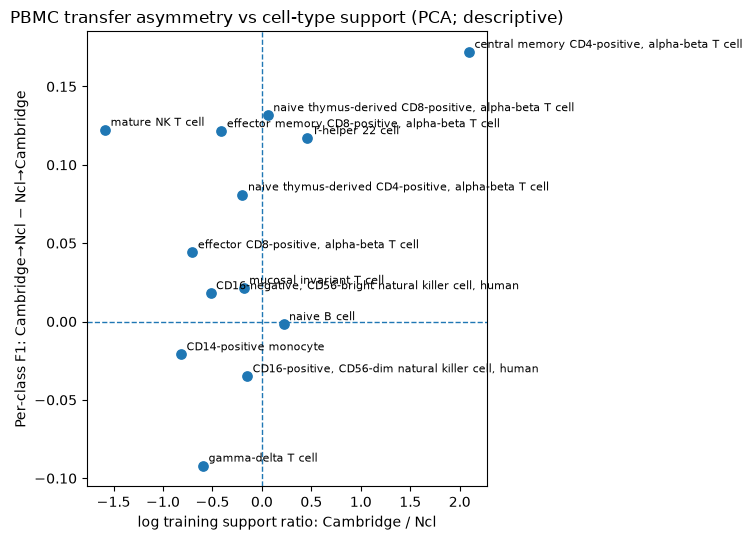

In [13]:
def _read_directional_per_class(train_group, test_group, rep):
    path = TRANSFER_DIR / f"group_transfer_{train_group}_to_{test_group}_{rep}_per_class_f1.csv"
    if not path.exists():
        # Keep this robust to slightly different historical naming.
        matches = sorted(TRANSFER_DIR.glob(f"*{train_group}*to*{test_group}*{rep}*per_class_f1.csv"))
        if not matches:
            return None
        path = matches[0]
    df = pd.read_csv(path)
    label_col = CELLTYPE_COL if CELLTYPE_COL in df.columns else "cell_type"
    return df.rename(columns={label_col: CELLTYPE_COL})[[CELLTYPE_COL, "f1"]]

PER_CLASS_REP = "pca"
fwd = _read_directional_per_class(GROUP_A, GROUP_B, PER_CLASS_REP)
rev = _read_directional_per_class(GROUP_B, GROUP_A, PER_CLASS_REP)
if fwd is None or rev is None:
    print("Per-class directional files were not found; skip this cell or update filename pattern.")
else:
    direction_support = support_table.reset_index().rename(columns={"index": CELLTYPE_COL})
    direction_support = direction_support.merge(
        fwd.rename(columns={"f1": "f1_Cambridge_to_Ncl"}), on=CELLTYPE_COL, how="left"
    ).merge(
        rev.rename(columns={"f1": "f1_Ncl_to_Cambridge"}), on=CELLTYPE_COL, how="left"
    )
    direction_support["delta_f1_Cambridge_to_Ncl_minus_reverse"] = (
        direction_support["f1_Cambridge_to_Ncl"] - direction_support["f1_Ncl_to_Cambridge"]
    )
    direction_support.to_csv(DIAG_DIR / f"direction_support_{PER_CLASS_REP}.csv", index=False)
    display(direction_support.sort_values("log_cell_support_ratio_Cambridge_over_Ncl"))

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.axhline(0, linewidth=1, linestyle="--")
    ax.axvline(0, linewidth=1, linestyle="--")
    ax.scatter(
        direction_support["log_cell_support_ratio_Cambridge_over_Ncl"],
        direction_support["delta_f1_Cambridge_to_Ncl_minus_reverse"],
        s=45,
    )
    for _, row in direction_support.dropna(subset=["delta_f1_Cambridge_to_Ncl_minus_reverse"]).iterrows():
        ax.annotate(row[CELLTYPE_COL], (
            row["log_cell_support_ratio_Cambridge_over_Ncl"],
            row["delta_f1_Cambridge_to_Ncl_minus_reverse"],
        ), xytext=(4, 3), textcoords="offset points", fontsize=8)
    ax.set_xlabel("log training support ratio: Cambridge / Ncl")
    ax.set_ylabel("Per-class F1: Cambridge→Ncl − Ncl→Cambridge")
    ax.set_title("PBMC transfer asymmetry vs cell-type support (PCA; descriptive)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "transfer_direction_vs_celltype_support_pca.png", dpi=300, bbox_inches="tight")
    plt.show()

## C. Cell-type support-matched transfer

For each repeat, each site is downsampled **within cell type** to the smaller site's count for that cell type. Then we train on the matched site sample and test on the full opposite site.

If the directional gap shrinks, unequal training support explains part of the asymmetry. If it persists, the evidence shifts toward genuine source/site domain shift.

In [14]:
SUPPORT_MATCH_RAW = DIAG_DIR / "support_matched_transfer_raw.csv"
SUPPORT_MATCH_SUMMARY = DIAG_DIR / "support_matched_transfer_summary.csv"
RUN_SUPPORT_MATCH = False  # set True once

if RUN_SUPPORT_MATCH or not SUPPORT_MATCH_RAW.exists():
    support_raw, support_sampling = run_support_matched_group_transfer(
        adata,
        REPRESENTATIONS,
        group_col=GROUP_COL,
        group_a=GROUP_A,
        group_b=GROUP_B,
        celltype_col=CELLTYPE_COL,
        n_repeats=10,
        seed=5000,
    )
    support_summary = summarize_transfer_sensitivity(support_raw)
    support_raw.to_csv(SUPPORT_MATCH_RAW, index=False)
    support_summary.to_csv(SUPPORT_MATCH_SUMMARY, index=False)
    support_sampling.to_csv(DIAG_DIR / "support_matched_training_counts.csv", index=False)
else:
    support_raw = pd.read_csv(SUPPORT_MATCH_RAW)
    support_summary = pd.read_csv(SUPPORT_MATCH_SUMMARY)

display(support_summary)

,analysis,representation,train_group,test_group,direction,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,n_runs
0,support_matched,harmony,Cambridge,Ncl,Cambridge_to_Ncl,0.734606,0.004108,0.820208,0.000911,10
1,support_matched,harmony,Ncl,Cambridge,Ncl_to_Cambridge,0.681605,0.002547,0.684670,0.001656,10
2,support_matched,hvg,Cambridge,Ncl,Cambridge_to_Ncl,0.716180,0.006864,0.804148,0.005879,10
3,support_matched,hvg,Ncl,Cambridge,Ncl_to_Cambridge,0.653025,0.012867,0.649016,0.020136,10
4,support_matched,pca,Cambridge,Ncl,Cambridge_to_Ncl,0.726147,0.004371,0.824489,0.003049,10
5,support_matched,pca,Ncl,Cambridge,Ncl_to_Cambridge,0.694154,0.006919,0.699109,0.005728,10
6,support_matched,scvi,Cambridge,Ncl,Cambridge_to_Ncl,0.707664,0.003285,0.809886,0.001450,10
7,support_matched,scvi,Ncl,Cambridge,Ncl_to_Cambridge,0.659155,0.002649,0.650963,0.001509,10


## D. Donor-count-matched transfer

Cambridge has 11 donors and Ncl 12 in the current transfer. This sensitivity repeatedly samples 11 donors from each site and reruns both directions. It directly tests whether the one-donor difference is a plausible explanation.

In [15]:
DONOR_MATCH_RAW = DIAG_DIR / "donor_count_matched_transfer_raw.csv"
DONOR_MATCH_SUMMARY = DIAG_DIR / "donor_count_matched_transfer_summary.csv"
RUN_DONOR_MATCH = False  # set True once

if RUN_DONOR_MATCH or not DONOR_MATCH_RAW.exists():
    donor_raw = run_donor_count_matched_group_transfer(
        adata,
        REPRESENTATIONS,
        group_col=GROUP_COL,
        group_a=GROUP_A,
        group_b=GROUP_B,
        celltype_col=CELLTYPE_COL,
        donor_col=DONOR_COL,
        n_repeats=10,
        seed=6000,
    )
    donor_summary = summarize_transfer_sensitivity(donor_raw)
    donor_raw.to_csv(DONOR_MATCH_RAW, index=False)
    donor_summary.to_csv(DONOR_MATCH_SUMMARY, index=False)
else:
    donor_raw = pd.read_csv(DONOR_MATCH_RAW)
    donor_summary = pd.read_csv(DONOR_MATCH_SUMMARY)

display(donor_summary)

,analysis,representation,train_group,test_group,direction,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,n_runs
0,donor_count_matched,harmony,Cambridge,Ncl,Cambridge_to_Ncl,0.712381,0.002640,0.785907,0.004931,10
1,donor_count_matched,harmony,Ncl,Cambridge,Ncl_to_Cambridge,0.677627,0.004195,0.679511,0.004559,10
2,donor_count_matched,hvg,Cambridge,Ncl,Cambridge_to_Ncl,0.708164,0.002280,0.781786,0.003913,10
3,donor_count_matched,hvg,Ncl,Cambridge,Ncl_to_Cambridge,0.656836,0.014466,0.654837,0.018715,10
4,donor_count_matched,pca,Cambridge,Ncl,Cambridge_to_Ncl,0.740478,0.003184,0.819747,0.005268,10
5,donor_count_matched,pca,Ncl,Cambridge,Ncl_to_Cambridge,0.688731,0.007282,0.692045,0.008936,10
6,donor_count_matched,scvi,Cambridge,Ncl,Cambridge_to_Ncl,0.695861,0.002823,0.772083,0.004834,10
7,donor_count_matched,scvi,Ncl,Cambridge,Ncl_to_Cambridge,0.652814,0.001665,0.646634,0.001513,10


## E. Compare original, support-matched, and donor-count-matched directional gaps

This is the compact decision plot. The original transfer summary is read from disk; no original benchmark rerun is needed.

,analysis,representation,direction_gap_Cambridge_to_Ncl_minus_reverse
0,original,harmony,0.036591
1,original,hvg,0.051382
2,original,pca,0.052195
3,original,scvi,0.041500
4,support matched,harmony,0.053001
5,support matched,hvg,0.063155
6,support matched,pca,0.031993
7,support matched,scvi,0.048510
8,donor-count matched,harmony,0.034754
9,donor-count matched,hvg,0.051328


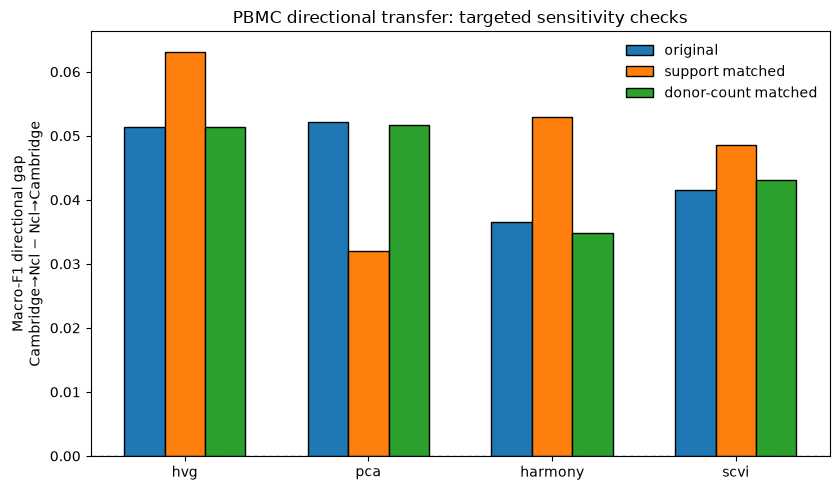

In [16]:
ORIGINAL_SUMMARY = TRANSFER_DIR / "group_transfer_summary.csv"
original = pd.read_csv(ORIGINAL_SUMMARY)
if "representation" not in original.columns and "rep" in original.columns:
    original = original.rename(columns={"rep": "representation"})

# Standardize direction labels.
if {"train_group", "test_group"}.issubset(original.columns):
    original["direction"] = original["train_group"].astype(str) + "_to_" + original["test_group"].astype(str)

orig_wide = original.pivot_table(index="representation", columns="direction", values="macro_f1", aggfunc="mean")
support_wide = support_summary.pivot_table(index="representation", columns="direction", values="macro_f1_mean", aggfunc="mean")
donor_wide = donor_summary.pivot_table(index="representation", columns="direction", values="macro_f1_mean", aggfunc="mean")

fwd_name = f"{GROUP_A}_to_{GROUP_B}"
rev_name = f"{GROUP_B}_to_{GROUP_A}"
comparison_rows = []
for analysis, wide in [
    ("original", orig_wide),
    ("support matched", support_wide),
    ("donor-count matched", donor_wide),
]:
    for rep in wide.index:
        if fwd_name in wide.columns and rev_name in wide.columns:
            comparison_rows.append({
                "analysis": analysis,
                "representation": rep,
                "direction_gap_Cambridge_to_Ncl_minus_reverse": wide.loc[rep, fwd_name] - wide.loc[rep, rev_name],
            })
comparison = pd.DataFrame(comparison_rows)
display(comparison)
comparison.to_csv(DIAG_DIR / "transfer_direction_gap_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8.5, 5))
analyses = ["original", "support matched", "donor-count matched"]
x = np.arange(len(REPRESENTATIONS))
width = 0.22
for j, analysis in enumerate(analyses):
    sub = comparison[comparison["analysis"].eq(analysis)].set_index("representation").reindex(REPRESENTATIONS.keys())
    ax.bar(x + (j - 1) * width, sub["direction_gap_Cambridge_to_Ncl_minus_reverse"], width, label=analysis, edgecolor="black")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(list(REPRESENTATIONS.keys()))
ax.set_ylabel("Macro-F1 directional gap\nCambridge→Ncl − Ncl→Cambridge")
ax.set_title("PBMC directional transfer: targeted sensitivity checks")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "transfer_direction_gap_sensitivities.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- If **support matching** substantially reduces the directional gap, unequal class-specific training support is an important explanation.
- If **11-vs-11 donor matching** leaves the gap essentially intact, overall donor count is not a useful explanation.
- If the gap persists after both checks, describe it as directional source/site domain shift and use the per-class table to identify which cell types drive it.

These are sensitivity analyses around the current transfer result, not a replacement evaluation framework.

## Correctness GLMM sensitivity

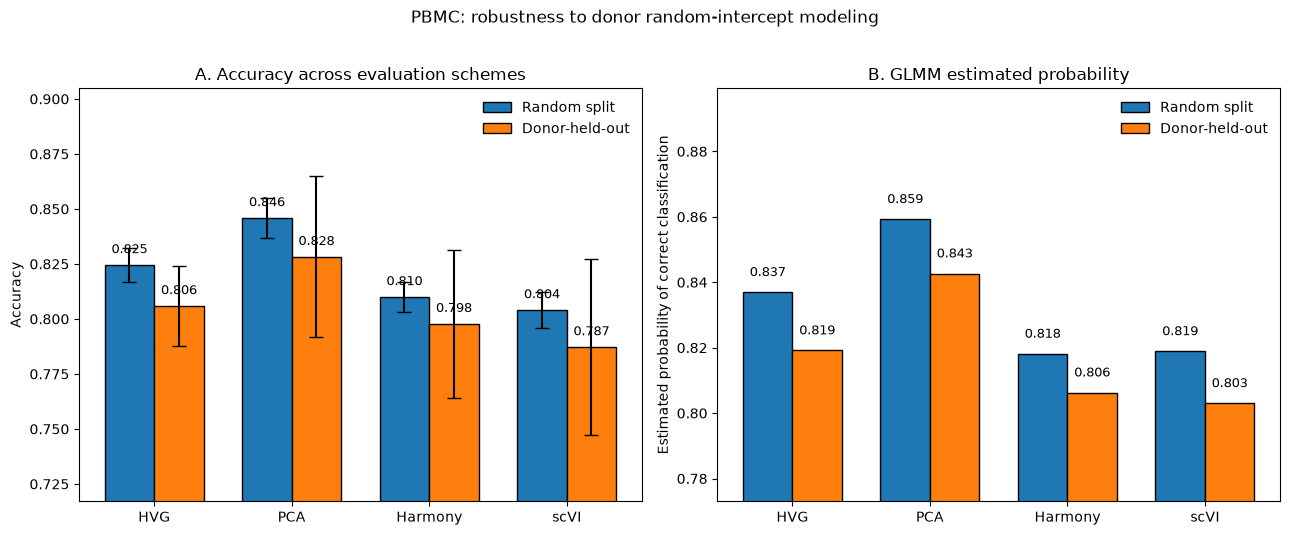

In [17]:
plot_glmm_scheme_comparison(
    PRIMARY_DIR / "random_split/random_split_repeated_metrics.csv",
    PRIMARY_DIR / "donor_cv/metrics.csv",
    PRIMARY_DIR / "mixed_models/correctness_glmm_predicted_probabilities.csv",
    out_file=FIG_DIR / "pbmc_glmm_scheme_comparison.pdf",
    title="PBMC: robustness to donor random-intercept modeling",
)
plt.show()

## Inflation-effect summary

,representation,random_macro_f1,donor_macro_f1,analysis,inflation_delta
0,harmony,0.777267,0.757633,No site covariate,0.019634
1,hvg,0.795859,0.768251,No site covariate,0.027608
2,pca,0.817465,0.790120,No site covariate,0.027345
3,scvi,0.769762,0.743892,No site covariate,0.025870
4,harmony,0.784136,0.759787,With site covariate,0.024349
5,hvg,0.795463,0.767941,With site covariate,0.027522
6,pca,0.816019,0.791469,With site covariate,0.024550
7,scvi,0.775809,0.743577,With site covariate,0.032231


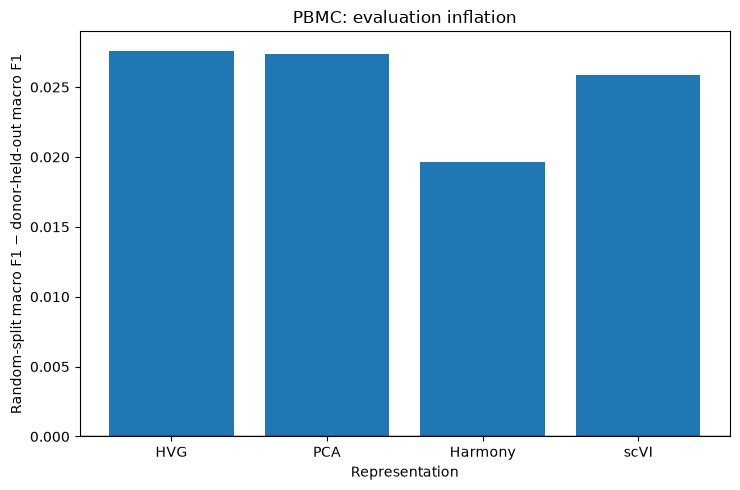

In [18]:
def inflation_table(result_dir, analysis_label):
    random_df = pd.read_csv(result_dir / "random_split/random_split_repeated_metrics.csv")
    donor_df = pd.read_csv(result_dir / "donor_cv/metrics.csv")
    random_mean = (
        random_df.groupby("representation", as_index=False)["macro_f1"].mean()
        .rename(columns={"macro_f1": "random_macro_f1"})
    )
    donor_keep = donor_df[["representation", "macro_f1_mean"]].rename(
        columns={"macro_f1_mean": "donor_macro_f1"}
    )
    out = random_mean.merge(donor_keep, on="representation", how="inner")
    out["analysis"] = analysis_label
    out["inflation_delta"] = out["random_macro_f1"] - out["donor_macro_f1"]
    return out

inflation = pd.concat(
    [
        inflation_table(PRIMARY_DIR, "No site covariate"),
        inflation_table(SITE_DIR, "With site covariate"),
    ],
    ignore_index=True,
)
display(inflation.sort_values(["analysis", "representation"]))
inflation.to_csv(CACHE_DIR / "pbmc_inflation_summary.csv", index=False)

primary = inflation[inflation["analysis"] == "No site covariate"].set_index("representation")
rep_order = [r for r in DEFAULT_REP_ORDER if r in primary.index]
vals = primary.reindex(rep_order)["inflation_delta"]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(np.arange(len(rep_order)), vals)
ax.axhline(0, linewidth=1, color="black")
ax.set_xticks(np.arange(len(rep_order)))
ax.set_xticklabels([DEFAULT_REP_LABELS.get(r, r) for r in rep_order])
ax.set_xlabel("Representation")
ax.set_ylabel("Random-split macro F1 − donor-held-out macro F1")
ax.set_title("PBMC: evaluation inflation")
fig.tight_layout()
fig.savefig(FIG_DIR / "pbmc_inflation_effect.pdf", bbox_inches="tight")
plt.show()